# NLS candidate-action scoring — completed curves

This notebook reads the canonical histories produced by `merge_downloaded_continuations.py`. Base and continuation W&B runs remain separate online, while the local curve is reconstructed on the original environment-step axis. At a continuation boundary, continuation data replaces any overlapping tail in the base run.

The training-curve analysis works before all full-test evaluations are available; the last section adds each full-test result automatically when its JSON file appears locally.

In [1]:
from pathlib import Path
import json, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 80)

def find_task_dir(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'main.py').is_file():
            return candidate
        nested = candidate / 'Topology_Task'
        if (nested / 'main.py').is_file():
            return nested
    raise RuntimeError('Could not locate Topology_Task')

TASK_DIR = find_task_dir()
GROUP_DIR = TASK_DIR / 'outputs' / 'run_data' / 'NLS_cas_hl'
MERGED_ROOT = GROUP_DIR / 'merged_runs'
BOUNDARY_PATH = GROUP_DIR / 'continuation_boundaries.csv'
FIG_DIR = TASK_DIR.parent / 'latex' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RUN_RE = re.compile(r'^cas_hl_NLS_(mean|tmean)_(f[01])_(a0h[01])_s0$')
METRIC_CANDIDATES = [
    'test/charts/episodic_survival',
    'test/episodic_survival',
]
SMOOTH_WINDOW = 7
print('task:', TASK_DIR)
print('canonical histories:', MERGED_ROOT)

task: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task
canonical histories: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/run_data/NLS_cas_hl/merged_runs


## Load and validate the reconstructed histories

In [2]:
manifest_path = GROUP_DIR / 'merged_manifest.csv'
if not manifest_path.exists():
    raise FileNotFoundError(
        f'Missing {manifest_path}. Run scripts/merge_downloaded_continuations.py first.'
    )
manifest = pd.read_csv(manifest_path)
boundaries = pd.read_csv(BOUNDARY_PATH) if BOUNDARY_PATH.exists() and BOUNDARY_PATH.stat().st_size else pd.DataFrame()

curves = {}
coverage_rows = []
for row in manifest.itertuples(index=False):
    match = RUN_RE.fullmatch(str(row.name))
    if match is None:
        continue
    history = pd.read_parquet(row.history_parquet)
    metric = next((key for key in METRIC_CANDIDATES if key in history and history[key].notna().any()), None)
    if metric is None:
        coverage_rows.append({'run_name': row.name, 'status': 'missing survival metric'})
        continue
    curve = history[['_step', metric, 'history_segment']].dropna(subset=[metric]).copy()
    curve['_step'] = pd.to_numeric(curve['_step'], errors='coerce')
    curve['survival_percent'] = 100 * pd.to_numeric(curve[metric], errors='coerce')
    curve = curve.dropna(subset=['_step', 'survival_percent']).sort_values('_step')
    curve = curve.groupby('_step', as_index=False).last()
    pool, features, head = match.groups()
    label = f'{pool}/{features}/{head}'
    curves[row.name] = {
        'label': label, 'pool': pool, 'features': features, 'a0_head': head,
        'metric': metric, 'data': curve, 'segments': int(row.segments),
    }
    coverage_rows.append({
        'run_name': row.name, 'label': label, 'segments': int(row.segments),
        'test_points': len(curve), 'first_test_step': int(curve._step.min()),
        'last_test_step': int(curve._step.max()), 'status': 'ok',
    })

coverage = pd.DataFrame(coverage_rows).sort_values('run_name')
display(coverage)
if len(curves) != 8:
    print(f'WARNING: expected 8 reconstructed cells, found {len(curves)}')
if not boundaries.empty:
    display(boundaries.sort_values(['base_run_name', 'start_step']))

,run_name,label,segments,test_points,first_test_step,last_test_step,status
0,cas_hl_NLS_mean_f0_a0h0_s0,mean/f0/a0h0,1,180,82944,14929920,ok
1,cas_hl_NLS_mean_f0_a0h1_s0,mean/f0/a0h1,1,180,82944,14929920,ok
2,cas_hl_NLS_mean_f1_a0h0_s0,mean/f1/a0h0,2,180,82944,14929920,ok
3,cas_hl_NLS_mean_f1_a0h1_s0,mean/f1/a0h1,1,180,82944,14929920,ok
4,cas_hl_NLS_tmean_f0_a0h0_s0,tmean/f0/a0h0,1,180,82944,14929920,ok
5,cas_hl_NLS_tmean_f0_a0h1_s0,tmean/f0/a0h1,1,180,82944,14929920,ok
6,cas_hl_NLS_tmean_f1_a0h0_s0,tmean/f1/a0h0,2,180,82944,14929920,ok
7,cas_hl_NLS_tmean_f1_a0h1_s0,tmean/f1/a0h1,2,180,82944,14929920,ok


,base_run_name,base_run_id,segment,continuation_run_name,continuation_run_id,start_step,end_step,previous_retained_step,gap_steps,rows
0,cas_hl_NLS_mean_f1_a0h0_s0,MAPPO_bus14_T_0_0__I__1786176392_48453,1,cas_hl_NLS_mean_f1_a0h0_s0 [continuation 65995...,cas_hl_NLS_mean_f1_a0h0_s0-cont-65995442,14390784,14971392,14349312,41472,15
1,cas_hl_NLS_tmean_f1_a0h0_s0,MAPPO_bus14_T_0_0__I__1786180713_31454,1,cas_hl_NLS_tmean_f1_a0h0_s0 [continuation 6599...,cas_hl_NLS_tmean_f1_a0h0_s0-cont-65995443,14224896,14971392,14183424,41472,19
2,cas_hl_NLS_tmean_f1_a0h1_s0,MAPPO_bus14_T_0_0__I__1786183549_33955,1,cas_hl_NLS_tmean_f1_a0h1_s0 [continuation 6599...,cas_hl_NLS_tmean_f1_a0h1_s0-cont-65995444,12897792,14971392,12856320,41472,51


## Periodic test survival during training

Dotted vertical lines mark the first logged step of a separate continuation run. They are provenance markers, not algorithmic events.

saved: /Users/corentinplumet/Documents/RL_Marl2grid/latex/figures/nls_cas_hl_completed_curves.png


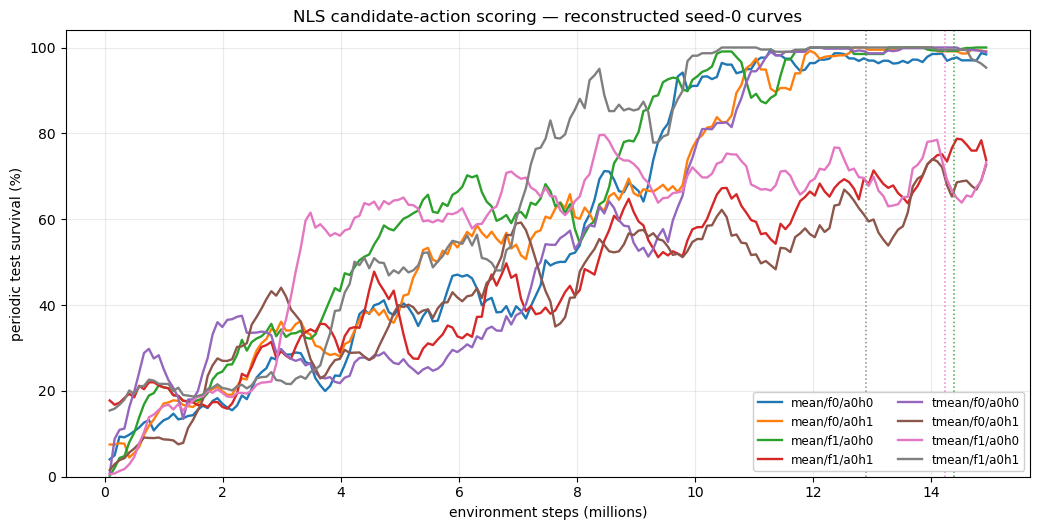

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
palette = plt.get_cmap('tab10')
colors = {}
for index, (run_name, item) in enumerate(sorted(curves.items(), key=lambda pair: pair[1]['label'])):
    curve = item['data']
    smooth = curve['survival_percent'].rolling(SMOOTH_WINDOW, min_periods=1, center=True).mean()
    color = palette(index)
    colors[run_name] = color
    ax.plot(curve['_step'] / 1e6, smooth, lw=1.7, color=color, label=item['label'])

if not boundaries.empty:
    for boundary in boundaries.itertuples(index=False):
        if boundary.base_run_name in colors:
            ax.axvline(boundary.start_step / 1e6, color=colors[boundary.base_run_name], ls=':', lw=1.1, alpha=0.9)

ax.set(xlabel='environment steps (millions)', ylabel='periodic test survival (%)', ylim=(0, 104))
ax.grid(alpha=0.25)
ax.legend(fontsize=8.5, ncol=2, loc='lower right', framealpha=0.92)
ax.set_title('NLS candidate-action scoring — reconstructed seed-0 curves')
fig.tight_layout()
figure_path = FIG_DIR / 'nls_cas_hl_completed_curves.png'
fig.savefig(figure_path, dpi=220)
print('saved:', figure_path)
plt.show()

## Training-curve summary

The maximum periodic evaluation is useful for diagnosing learning, but it is not a substitute for the 201-chronic full-test evaluation of the saved best checkpoint.

In [4]:
summary_rows = []
for run_name, item in curves.items():
    curve = item['data']
    best_index = curve['survival_percent'].idxmax()
    final_window = curve.tail(min(5, len(curve)))
    summary_rows.append({
        'run_name': run_name, 'cell': item['label'], 'pool': item['pool'],
        'features': item['features'], 'a0_head': item['a0_head'],
        'segments': item['segments'], 'test_points': len(curve),
        'best_periodic_survival': curve.loc[best_index, 'survival_percent'],
        'best_periodic_step': int(curve.loc[best_index, '_step']),
        'last_periodic_survival': curve.iloc[-1]['survival_percent'],
        'last5_periodic_mean': final_window['survival_percent'].mean(),
        'last_test_step': int(curve.iloc[-1]['_step']),
    })
training_summary = pd.DataFrame(summary_rows).sort_values('best_periodic_survival', ascending=False).reset_index(drop=True)
display(training_summary.round(3))

,run_name,cell,pool,features,a0_head,segments,test_points,best_periodic_survival,best_periodic_step,last_periodic_survival,last5_periodic_mean,last_test_step
0,cas_hl_NLS_mean_f0_a0h0_s0,mean/f0/a0h0,mean,f0,a0h0,1,180,100.000,9704448,100.000,98.715,14929920
1,cas_hl_NLS_mean_f0_a0h1_s0,mean/f0/a0h1,mean,f0,a0h1,1,180,100.000,10865664,100.000,99.272,14929920
2,cas_hl_NLS_mean_f1_a0h0_s0,mean/f1/a0h0,mean,f1,a0h0,2,180,100.000,10202112,100.000,100.000,14929920
3,cas_hl_NLS_tmean_f0_a0h0_s0,tmean/f0/a0h0,tmean,f0,a0h0,1,180,100.000,10119168,100.000,99.200,14929920
4,cas_hl_NLS_tmean_f1_a0h1_s0,tmean/f1/a0h1,tmean,f1,a0h1,2,180,100.000,7796736,81.209,96.242,14929920
5,cas_hl_NLS_mean_f1_a0h1_s0,mean/f1/a0h1,mean,f1,a0h1,1,180,96.920,14598144,62.883,78.391,14929920
6,cas_hl_NLS_tmean_f1_a0h0_s0,tmean/f1/a0h0,tmean,f1,a0h0,2,180,91.591,13934592,82.899,68.879,14929920
7,cas_hl_NLS_tmean_f0_a0h1_s0,tmean/f0/a0h1,tmean,f0,a0h1,1,180,85.458,13934592,63.310,69.093,14929920


## Complete full-test results and comparison with the unprocessed inputs

All eight selected checkpoints have now been evaluated deterministically on the 201 held-out chronics. The NLS condition combines physical scaling with the edge-difference angle representation; running graph standardization remains disabled. These runs share the GNN encoder across agents, but retain one candidate-action MLP scorer per agent. The NL comparison below changes the input preprocessing only.

,cell,segments,best_periodic_survival,best_periodic_step,last5_periodic_mean,full_test_survival,checkpoint_step,eval_episodes,valid_protocol
0,mean/f1/a0h0,2,100.000,10202112,100.000,100.000,14929920,201,True
1,tmean/f0/a0h0,1,100.000,10119168,99.200,99.837,14929920,201,True
2,mean/f0/a0h1,1,100.000,10865664,99.272,99.457,14929920,201,True
3,mean/f0/a0h0,1,100.000,9704448,98.715,99.428,14929920,201,True
4,tmean/f1/a0h1,2,100.000,7796736,96.242,90.710,14846976,201,True
5,mean/f1/a0h1,1,96.920,14598144,78.391,83.809,14598144,201,True
6,tmean/f1/a0h0,2,91.591,13934592,68.879,71.673,13934592,201,True
7,tmean/f0/a0h1,1,85.458,13934592,69.093,69.666,14764032,201,True


valid NLS full-test coverage: 8 / 8


,cell,NL_survival,NLS_survival,delta_NLS_minus_NL,NL_checkpoint_step,NLS_checkpoint_step
0,mean/f1/a0h0,98.325,100.000,1.675,14846976,14929920
1,tmean/f0/a0h0,92.505,99.837,7.332,12358656,14929920
2,mean/f0/a0h1,99.523,99.457,-0.066,14929920,14929920
3,mean/f0/a0h0,99.180,99.428,0.248,14929920,14929920
4,tmean/f1/a0h1,57.835,90.710,32.875,11612160,14846976
5,mean/f1/a0h1,98.660,83.809,-14.851,14929920,14598144
6,tmean/f1/a0h0,99.496,71.673,-27.823,14929920,13934592
7,tmean/f0/a0h1,98.172,69.666,-28.505,14764032,14764032


saved: /Users/corentinplumet/Documents/RL_Marl2grid/latex/figures/candidate_action_preprocessing_fulltest.png


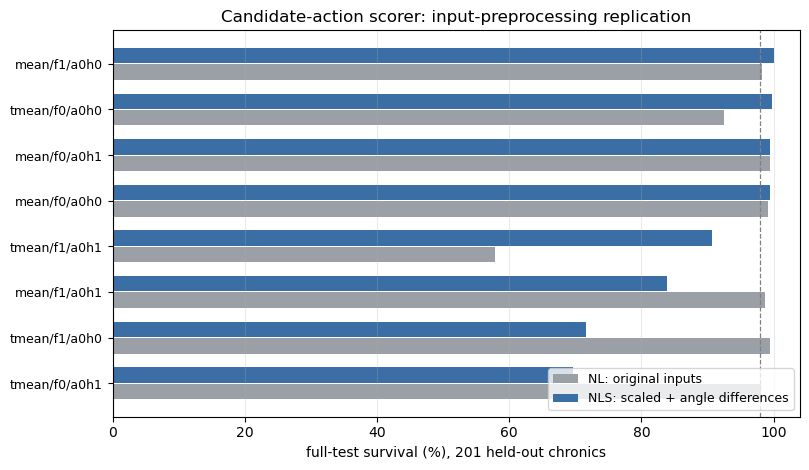

,factor,level,NLS_survival
0,pool,mean,95.674
1,pool,tmean,82.971
2,descriptor,f0,92.097
3,descriptor,f1,86.548
4,idle head,a0h0,92.734
5,idle head,a0h1,85.911


NLS cells at or above 98%: 4 of 8
Mean paired change (NLS - NL): -3.639 percentage points


In [5]:
FULL_TEST_ROOT = TASK_DIR / 'outputs' / 'full_test_eval'

def load_full_test(folder, run_pattern, preprocessing):
    rows = []
    for path in sorted(folder.glob('*.json')):
        payload = json.loads(path.read_text(encoding='utf-8'))
        identity = f"{path.name} {payload.get('checkpoint', '')}"
        match = re.search(run_pattern, identity)
        if match is None:
            continue
        survival = payload.get('survival_percent')
        if survival is None and payload.get('survival_frac') is not None:
            survival = 100 * float(payload['survival_frac'])
        valid_protocol = (
            payload.get('split') == 'test'
            and bool(payload.get('deterministic_eval'))
            and bool(payload.get('eval_all_split_chronics'))
            and int(payload.get('eval_episodes', 0)) == 201
            and payload.get('obs_normalization') == 'checkpoint_stats'
            and bool(payload.get('obs_stats_available'))
            and not bool(payload.get('gnn_running_norm_effective'))
            and bool(payload.get('gnn_physical_scaling_effective')) == (preprocessing == 'NLS')
        )
        rows.append({
            'run_name': match.group(1), 'preprocessing': preprocessing,
            'full_test_survival': float(survival),
            'checkpoint_step': int(payload['checkpoint_global_step']),
            'eval_episodes': int(payload['eval_episodes']),
            'valid_protocol': valid_protocol,
            'created_at': payload.get('created_at', ''),
            'result_path': str(path.relative_to(TASK_DIR)),
        })
    return pd.DataFrame(rows).sort_values('created_at').drop_duplicates('run_name', keep='last')

nls_full_test = load_full_test(
    FULL_TEST_ROOT / 'NLS_cas_hl',
    r'(cas_hl_NLS_(?:mean|tmean)_f[01]_a0h[01]_s0)',
    'NLS',
)
nl_full_test = load_full_test(
    FULL_TEST_ROOT / 'NL_cas_hl',
    r'(cas_hl_NL_(?:mean|tmean)_f[01]_a0h[01]_s0)',
    'NL',
)
assert len(nls_full_test) == 8 and bool(nls_full_test['valid_protocol'].all()), nls_full_test
assert len(nl_full_test) == 8 and bool(nl_full_test['valid_protocol'].all()), nl_full_test

results = training_summary.merge(nls_full_test, on='run_name', how='left')
results = results.sort_values('full_test_survival', ascending=False).reset_index(drop=True)
display(results[[
    'cell', 'segments', 'best_periodic_survival', 'best_periodic_step',
    'last5_periodic_mean', 'full_test_survival', 'checkpoint_step',
    'eval_episodes', 'valid_protocol'
]].round(3))
print(f"valid NLS full-test coverage: {len(results)} / {len(training_summary)}")

def cell_from_run_name(name):
    match = re.search(r'_(mean|tmean)_(f[01])_(a0h[01])_s0$', name)
    return '/'.join(match.groups())

nl_compare = nl_full_test.copy()
nl_compare['cell'] = nl_compare['run_name'].map(cell_from_run_name)
nl_compare = nl_compare.rename(columns={
    'full_test_survival': 'NL_survival', 'checkpoint_step': 'NL_checkpoint_step'
})
paired = results.merge(
    nl_compare[['cell', 'NL_survival', 'NL_checkpoint_step']], on='cell', how='left'
)
paired = paired.rename(columns={
    'full_test_survival': 'NLS_survival', 'checkpoint_step': 'NLS_checkpoint_step'
})
paired['delta_NLS_minus_NL'] = paired['NLS_survival'] - paired['NL_survival']
paired = paired.sort_values('NLS_survival', ascending=False).reset_index(drop=True)
display(paired[[
    'cell', 'NL_survival', 'NLS_survival', 'delta_NLS_minus_NL',
    'NL_checkpoint_step', 'NLS_checkpoint_step'
]].round(3))

plot_data = paired.sort_values('NLS_survival', ascending=True).reset_index(drop=True)
y = np.arange(len(plot_data))
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.barh(y - 0.18, plot_data['NL_survival'], height=0.34, color='#9aa0a6', label='NL: original inputs')
ax.barh(y + 0.18, plot_data['NLS_survival'], height=0.34, color='#3b6ea5', label='NLS: scaled + angle differences')
ax.set_yticks(y, plot_data['cell'], fontsize=9)
ax.set(xlim=(0, 104), xlabel='full-test survival (%), 201 held-out chronics')
ax.axvline(98, color='grey', ls='--', lw=0.9)
ax.grid(axis='x', alpha=0.25)
ax.legend(fontsize=9, loc='lower right')
ax.set_title('Candidate-action scorer: input-preprocessing replication')
fig.tight_layout()
comparison_figure_path = FIG_DIR / 'candidate_action_preprocessing_fulltest.png'
fig.savefig(comparison_figure_path, dpi=220)
print('saved:', comparison_figure_path)
plt.show()

factor_marginals = pd.concat([
    paired.groupby('pool', as_index=False)['NLS_survival'].mean().rename(columns={'pool': 'level'}).assign(factor='pool'),
    paired.groupby('features', as_index=False)['NLS_survival'].mean().rename(columns={'features': 'level'}).assign(factor='descriptor'),
    paired.groupby('a0_head', as_index=False)['NLS_survival'].mean().rename(columns={'a0_head': 'level'}).assign(factor='idle head'),
], ignore_index=True)
display(factor_marginals[['factor', 'level', 'NLS_survival']].round(3))
print('NLS cells at or above 98%:', int((paired['NLS_survival'] >= 98).sum()), 'of', len(paired))
print('Mean paired change (NLS - NL):', round(paired['delta_NLS_minus_NL'].mean(), 3), 'percentage points')